### installs

установка требуемых зависимостей

In [1]:
!pip install --upgrade "optimum[exporters,onnxruntime]" onnx skl2onnx netron tf2onnx onnxscript onnxruntime onnxoptimizer onnxsim

  Using cached onnxruntime-1.26.0-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
Using cached onnxruntime-1.26.0-cp314-cp314-win_amd64.whl (13.3 MB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install --upgrade accelerate torch transformers pandas numpy scikit-learn matplotlib datasets seaborn

  Using cached transformers-5.9.0-py3-none-any.whl.metadata (33 kB)
Using cached transformers-5.9.0-py3-none-any.whl (10.8 MB)
   ---------------------------------------- 0.0/671.5 kB ? eta -:--:--
   --------------- ------------------------ 262.1/671.5 kB ? eta -:--:--
   ---------------------------------------- 671.5/671.5 kB 4.7 MB/s  0:00:00

  Attempting uninstall: huggingface_hub

    Found existing installation: huggingface_hub 0.36.2

    Uninstalling huggingface_hub-0.36.2:

      Successfully uninstalled huggingface_hub-0.36.2

   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
  Attempting uninstall: transformers
   ---------------------------------------- 0/2 [huggingface_hub]
    Found existing installation: transformers 4.57.6
   ---------------------------------------- 0/2 [huggingface_hub]
   -------------------- ------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
optimum-onnx 0.1.0 requires transformers<4.58.0,>=4.36, but you have transformers 5.9.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### imports

импорты пакетов

In [2]:
import torch
import torch.nn as nn
import torch.onnx

import onnx
from onnx import helper, numpy_helper, TensorProto
from onnxsim import simplify
from onnxoptimizer import optimize
import onnxruntime as ort

In [3]:
import numpy as np
import pandas as pd
import random

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig
from transformers import Trainer, TrainingArguments, set_seed

import re
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# здесь фиксируем все рандомстейты, чтобы сохранять повторяемость экспериментов. 
# если этого не делать, веса будут инициализироваться каждый раз разные, и мы будем получать небольшие различия на выходе
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [5]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

In [6]:
# проверка доступности CUDA на машине 
print(torch.__version__)
print(torch.cuda.is_available())   
print(torch.cuda.get_device_name(0))

2.12.0+cu132
True
NVIDIA GeForce RTX 4070 Laptop GPU


### простые модели и их визуализация в netron

задача - обернуть модель линейной регрессии в .onnx и визуализировать граф модели через netron

In [22]:
X = np.array([[1.0], [2.0], [3.0], [4.0]], dtype=np.float32)

coef: int = 5
y = np.array([t[0] * coef for t in X], dtype=np.float32)

model_sk = LinearRegression().fit(X, y)
coef = model_sk.coef_[0]
intercept = model_sk.intercept_

In [23]:
class SimpleLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1, bias=True)
        self.linear.weight.data = torch.tensor([[coef]], dtype=torch.float32)
        self.linear.bias.data = torch.tensor([intercept], dtype=torch.float32)

    def forward(self, x):
        return self.linear(x)

torch_model = SimpleLinear()
torch_model.eval()

SimpleLinear(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [3]:
dummy_input = torch.randn(1, 1, dtype=torch.float32)

torch.onnx.export(
    torch_model,
    dummy_input,
    "some path",
    input_names=["float_input"],
    output_names=["variable"],
    opset_version=17,
    do_constant_folding=True
)

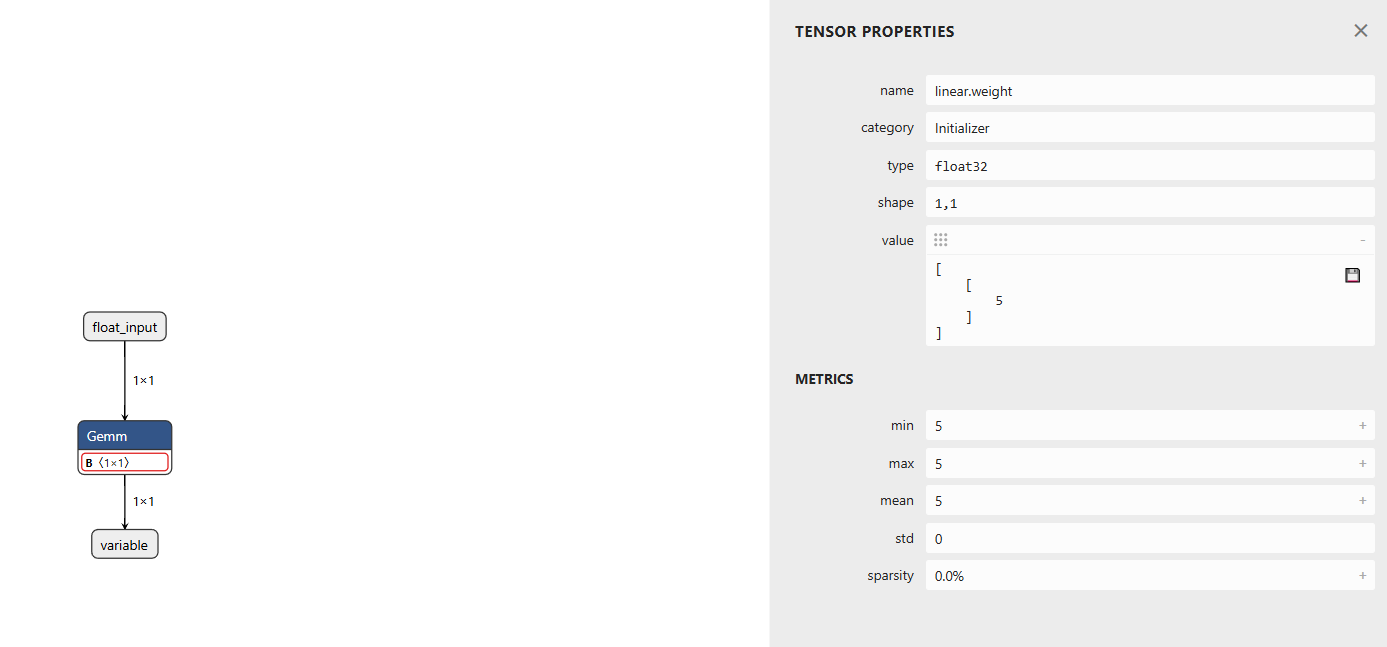

теперь соберем модель чуть сложнее. в ней будут операции матричного умножения, сложения, функция активации

In [27]:
input_tensor = helper.make_tensor_value_info("input", TensorProto.FLOAT, [None, 1])
output_tensor = helper.make_tensor_value_info("output", TensorProto.FLOAT, [None, 1])

In [28]:
w1 = numpy_helper.from_array(np.array([[3.0]], dtype=np.float32), name="w1")
b1 = numpy_helper.from_array(np.array([[2.0]], dtype=np.float32), name="b1")
w2 = numpy_helper.from_array(np.array([[0.5]], dtype=np.float32), name="w2")
b2 = numpy_helper.from_array(np.array([[4.0]], dtype=np.float32), name="b2")

In [29]:
nodes = [
    # шаг 1. x * 3.0
    helper.make_node("MatMul", ["input", "w1"], ["mul1_out"], name="MatMul1"),
    
    # шаг 2. (x*3) + 2.0
    helper.make_node("Add", ["mul1_out", "b1"], ["add1_out"], name="Add1"),
    
    # шаг 3. ReLU( (x*3)+2 )
    helper.make_node("Relu", ["add1_out"], ["relu_out"], name="Relu"),
    
    # шаг 4. x * 0.5
    helper.make_node("MatMul", ["input", "w2"], ["mul2_out"], name="MatMul2"),
    
    # шаг 5. ReLU( (x*3)+2 ) + (x*0.5)
    helper.make_node("Add", ["relu_out", "mul2_out"], ["output"], name="Add2"),
]

In [4]:
graph = helper.make_graph(
    nodes=nodes,
    name="MultiNodeModel",
    inputs=[input_tensor],
    outputs=[output_tensor],
    initializer=[w1, b1, w2, b2]
)

model = helper.make_model(graph, opset_imports=[helper.make_opsetid("", 17)])

onnx.save(model, "some path")

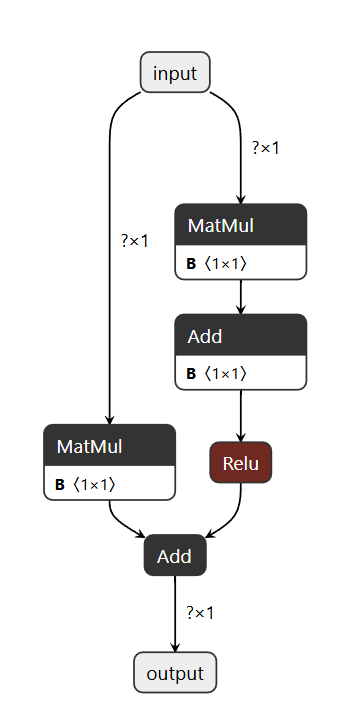

проиницализируем сессию через рантайм и посмотрим на предсказания модели. можно пройтись по графу глазами и посчитать вручную, модель отдает корректные предсказания

In [37]:
session = ort.InferenceSession("some path")

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

X_test = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]], dtype=np.float32)

print("model preds:")
for x in X_test:
    input_data = {input_name: x.reshape(1, 1)}   
    pred = session.run([output_name], input_data)[0]
    print(f"x = {x[0]:4.1f}  →  y = {pred[0][0]:6.3f}")

model preds:
x =  1.0  →  y =  5.500
x =  2.0  →  y =  9.000
x =  3.0  →  y = 12.500
x =  4.0  →  y = 16.000
x =  5.0  →  y = 19.500


теперь сделаем модель с нодами matmul и add. далее объединим matmul и add в одну ноду - Gemm

In [5]:
input_info = helper.make_tensor_value_info("input", TensorProto.FLOAT, [None, 1])
output_info = helper.make_tensor_value_info("output", TensorProto.FLOAT, [None, 1])

weight = numpy_helper.from_array(np.array([[4.0]], dtype=np.float32), name="weight")
bias   = numpy_helper.from_array(np.array([[1.5]], dtype=np.float32), name="bias")

nodes = [
    helper.make_node("MatMul", ["input", "weight"], ["matmul_out"], name="MatMul_0"),
    helper.make_node("Add",    ["matmul_out", "bias"], ["output"], name="Add_0"),
]

graph = helper.make_graph(
    nodes=nodes,
    name="SplitLinearModel",
    inputs=[input_info],
    outputs=[output_info],
    initializer=[weight, bias]
)

model = helper.make_model(graph, opset_imports=[helper.make_opsetid("", 17)])
onnx.save(model, "some path")

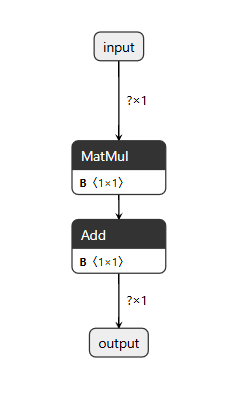

In [39]:
input_info = helper.make_tensor_value_info("input", TensorProto.FLOAT, [None, 1])
output_info = helper.make_tensor_value_info("output", TensorProto.FLOAT, [None, 1])

weight = numpy_helper.from_array(np.array([[4.0]], dtype=np.float32), name="weight")
bias   = numpy_helper.from_array(np.array([1.5], dtype=np.float32), name="bias")  # note: shape (1,)

nodes = [
    helper.make_node(
        "Gemm",
        ["input", "weight", "bias"],
        ["output"],
        name="Gemm_0",
        alpha=1.0,
        beta=1.0,
        transA=0,
        transB=1
    )
]

graph = helper.make_graph(
    nodes=nodes,
    name="FusedLinearModel",
    inputs=[input_info],
    outputs=[output_info],
    initializer=[weight, bias]
)

model = helper.make_model(graph, opset_imports=[helper.make_opsetid("", 17)])
onnx.save(model, "some path")

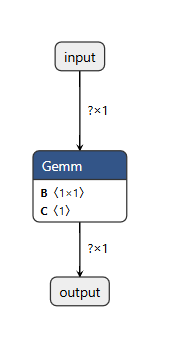

здесь пример работы SliceElimination и identityElimination

In [23]:
onnxoptimizer.get_available_passes()

['adjust_add',
 'rename_input_output',
 'set_unique_name_for_nodes',
 'nop',
 'eliminate_nop_cast',
 'eliminate_nop_dropout',
 'eliminate_nop_flatten',
 'extract_constant_to_initializer',
 'eliminate_consecutive_idempotent_ops',
 'eliminate_if_with_const_cond',
 'eliminate_nop_monotone_argmax',
 'eliminate_nop_pad',
 'eliminate_nop_concat',
 'eliminate_nop_split',
 'eliminate_nop_expand',
 'eliminate_shape_gather',
 'eliminate_slice_after_shape',
 'eliminate_nop_transpose',
 'fuse_add_bias_into_conv',
 'fuse_bn_into_conv',
 'fuse_consecutive_concats',
 'fuse_consecutive_log_softmax',
 'fuse_consecutive_reduce_unsqueeze',
 'fuse_consecutive_squeezes',
 'fuse_consecutive_transposes',
 'fuse_matmul_add_bias_into_gemm',
 'fuse_pad_into_conv',
 'fuse_pad_into_pool',
 'fuse_transpose_into_gemm',
 'replace_einsum_with_matmul',
 'lift_lexical_references',
 'split_init',
 'split_predict',
 'fuse_concat_into_reshape',
 'eliminate_nop_reshape',
 'eliminate_nop_with_unit',
 'eliminate_common_subex

In [26]:
input_info = helper.make_tensor_value_info("input", TensorProto.FLOAT, [1, 1])
output_info = helper.make_tensor_value_info("output", TensorProto.FLOAT, [1, 1])

weight = numpy_helper.from_array(np.array([[3.0]], dtype=np.float32), name="weight")
bias   = numpy_helper.from_array(np.array([[2.0]], dtype=np.float32), name="bias")

nodes = [
    helper.make_node("MatMul", ["input", "weight"], ["matmul_out"], name="MatMul_0"),
    
    # identity нода, которую должен удалить identityElimination
    helper.make_node("Identity", ["matmul_out"], ["identity_out"], name="Identity_0"),
    
    helper.make_node("Slice",
                     ["identity_out", "starts", "ends"],
                     ["slice_out"],
                     name="Slice_0"),
    
    helper.make_node("Add", ["slice_out", "bias"], ["output"], name="Add_0"),
]

starts = numpy_helper.from_array(np.array([0], dtype=np.int64), name="starts")
ends   = numpy_helper.from_array(np.array([1], dtype=np.int64), name="ends")

graph = helper.make_graph(
    nodes=nodes,
    name="DirtyModel",
    inputs=[input_info],
    outputs=[output_info],
    initializer=[weight, bias, starts, ends]
)

model_dirty = helper.make_model(graph, opset_imports=[helper.make_opsetid("", 17)])
onnx.save(model_dirty, "some path")

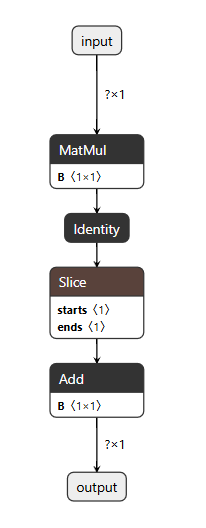

In [29]:
import onnxruntime as ort
import os

model_path = r"some path"
optimized_path = r"some path"


sess_options = ort.SessionOptions()
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL   
sess_options.optimized_model_filepath = optimized_path

_ = ort.InferenceSession(model_path, sess_options, providers=['CPUExecutionProvider'])

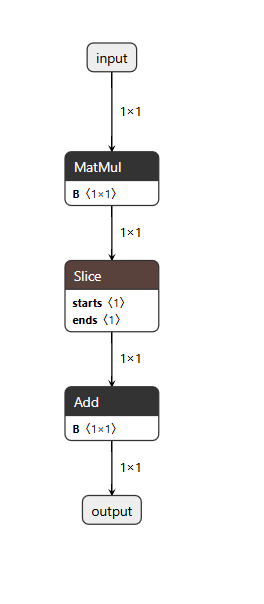

как видно, иногда слайс-нода не уничтожается во время оптимизации, а связано это с тем, что SliceElimination имеет очень строгие правила удаления нод. поэтому иногда слайс-ноды могут оставаться, поскольку не попадают под эти правила

### LLM

обучим deepvk/rumodernbert-base на классификацию текста по эмоциональной окраске, 3 класса. далее обернем в onnx, проведем компиляцию под видеокарту и замерим разницу в скорости инференса

In [6]:
train_df: pd.DataFrame = pd.read_csv('some path')
train_df['labels'] = train_df['label_name']
train_df = train_df[['question', 'labels']]

train_df.head()

In [7]:
# здесь разделение исходного датафрейма на тройку трейн-тест-валид
train_df['question'] = train_df['question'].apply(lambda x: x.lower().strip())

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["labels"],
    random_state=42
)

train_df = train_df.sample(frac=1)
train_df['labels'].value_counts()

In [10]:
labels = train_df["labels"].unique()
num_labels = len(labels)

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

train_df["label"] = train_df["labels"].apply(lambda x: label2id[x])
val_df["label"] = val_df["labels"].apply(lambda x: label2id[x])

In [11]:
train_split, valid_split = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"]
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_split, preserve_index=False),
    "valid": Dataset.from_pandas(valid_split, preserve_index=False),
})

val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

In [27]:
pass

In [28]:
pass

In [15]:
model_id = 'deepvk/RuModernBERT-small' 
device = 'cuda'

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.model_max_length = 512
tokenizer.truncation_side = 'left'

In [16]:
def tokenize(batch):
    return tokenizer(batch['question'], padding='max_length', truncation=True).to(device)

tokenized_dataset = dataset.map(tokenize, batched=False, remove_columns=["question"])
val_dataset = val_dataset.map(tokenize, batched=False, remove_columns=["question"])

Map:   0%|          | 0/9740 [00:00<?, ? examples/s]

Map:   0%|          | 0/1083 [00:00<?, ? examples/s]

Map:   0%|          | 0/1203 [00:00<?, ? examples/s]

In [17]:
# поскольку у нас нет более важного класса, чем другие, целевая метрика - acc. надо классифициировать все хорошо
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    
    return {
        "accuracy": acc,
        "f1": f1,
    }

In [18]:
device = torch.device("cuda")

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    # attn_implementation="flash_attention_2",  # flash_attn долго ставить, поэтому я обучал без него

    attention_probs_dropout_prob=0.2,
    embed_dropout_prob=0.2,
    mlp_dropout=0.2,
    classifier_dropout=0.1
).to(device)

training_args = TrainingArguments(
    output_dir=None,          
    save_strategy="no",              
    eval_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=4e-5,
    num_train_epochs=3,
    weight_decay=0.1,
    warmup_ratio=0.1,
    gradient_accumulation_steps=1,
    max_grad_norm=1.0,
    seed=42,
    metric_for_best_model="accuracy",
    fp16=True,
    bf16=False,
    logging_dir=None
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["valid"],
    compute_metrics=compute_metrics
)

trainer.train()

W0527 19:00:56.346000 18688 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at deepvk/RuModernBERT-small and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.171432,0.943675,0.945599
2,0.659800,0.108235,0.961219,0.963745
3,0.659800,0.104615,0.970452,0.972450


TrainOutput(global_step=915, training_loss=0.41061471407530736, metrics={'train_runtime': 269.3449, 'train_samples_per_second': 108.485, 'train_steps_per_second': 3.397, 'total_flos': 1364364767969280.0, 'train_loss': 0.41061471407530736, 'epoch': 3.0})

In [19]:
# валидация на отложенной выборке
predictions = trainer.predict(val_dataset)
preds = predictions.predictions.argmax(axis=-1)
labels = predictions.label_ids

acc = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
print({"accuracy": acc, "precision": precision, "recall": recall, "f1": f1})

{'accuracy': 0.970906068162926, 'precision': 0.9709341324327537, 'recall': 0.970906068162926, 'f1': 0.9709067515205816}


In [8]:
model.save_pretrained('some path')
tokenizer.save_pretrained('some path')

модель есть, теперь проведем ее обычный инференс и замерим скорость и качество ответа до оптимизаций графа

In [9]:
class RuModernBERTClassifier:
    def __init__(self, model_path):
        self.device = torch.device('cpu') # 'cuda' if torch.cuda.is_available() else 'cpu')
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        print(f"Using device: {self.device}")        
        
        self.id2label = self.model.config.id2label
        self.label2id = self.model.config.label2id
        print(f"Available classes: {self.id2label}")
        
        self.model = self.model.to(self.device)
        self.model.eval()
        
    def get_confidence(self, text, return_logits=False):
        inputs = self.tokenizer(
            text, 
            return_tensors="pt", 
            truncation=True, 
            padding=True, 
            max_length=512
        )
        
        inputs = {key: value.to(self.device) for key, value in inputs.items()}
        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits
            probabilities = torch.softmax(logits, dim=-1)
            
        probabilities = probabilities.cpu()
        logits = logits.cpu()
        
        confidence, predicted_class_idx = torch.max(probabilities, dim=-1)
        predicted_class_name = self.id2label.get(predicted_class_idx.item(), "Unknown")
        
        class_probabilities = {}
        for class_idx, prob in enumerate(probabilities[0]):
            class_name = self.id2label.get(class_idx, f"Class_{class_idx}")
            class_probabilities[class_name] = prob.item()
        
        result = {
            'predicted_class': predicted_class_name,
            'confidence': confidence.item(),
            'probabilities': class_probabilities  
        }
        
        if return_logits:
            result['logits'] = logits.numpy()[0].tolist()
            
        return result

    def get_all_classes(self):
        return [self.id2label[i] for i in range(len(self.id2label))]

model_path = 'some path'
classifier = RuModernBERTClassifier(model_path)

In [13]:
import time

temp_df: pandas. DataFrame = val_df
temp_df = temp_df[['question', 'labels']]
temp_df = temp_df.sample(500).reset_index(drop=True)

In [14]:
total_correct: int = 0
total_incorrect: int = 0
processing_times: list = []

for ind in range(len(temp_df)):
    question = temp_df.loc[ind, 'question']
    
    start_time = time.perf_counter()
    model_pred = classifier.get_confidence(question)['predicted_class']
    end_time = time.perf_counter()
    processing_times.append(end_time - start_time)
    
    correct_answer = temp_df.loc[ind, 'labels']
    if model_pred == correct_answer:
        total_correct += 1

    else:
        total_incorrect += 1

total_correct, total_incorrect

(489, 11)

поскольку мы замеряем acc, целевая метрика достигла ~0.97, что очень хороший результат, несмотря на простоту задачи (подразумеваем, что у нас нет ошибок разметки). теперь отобразим среднее время ответа модели на запрос

In [15]:
mean_req_processing_time = {
    "standard": round(sum(processing_times) / len(processing_times), 4)
}
mean_req_processing_time

{'standard': 0.0107}

далее преобразуем модель в ONNX и проведем ее инференс через ONNX Runtime с целью убедиться, что при переносе потери качества не произошло

In [10]:
from optimum.onnxruntime import ORTModelForSequenceClassification
from transformers import AutoConfig

model_path = 'some path'
config = AutoConfig.from_pretrained(model_path)
config.attn_implementation = "eager"

ort_model = ORTModelForSequenceClassification.from_pretrained(
    model_path, export=True, config=config, provider="CUDAExecutionProvider",
)

onnx_save_dir = "some path"
ort_model.save_pretrained(onnx_save_dir)

In [11]:
import torch
import onnxruntime as ort
import numpy as np
from transformers import AutoTokenizer, AutoConfig

class RuModernBERTONNXClassifier:
    def __init__(self, onnx_dir: str, original_model_path: str):
        available_providers = ort.get_available_providers()
        providers = ["CUDAExecutionProvider"]
        
        self.session = ort.InferenceSession(
            f"{onnx_dir}/model.onnx",
            providers=providers
        )
        
        self.tokenizer = AutoTokenizer.from_pretrained(original_model_path)
        config = AutoConfig.from_pretrained(original_model_path)
        self.id2label = config.id2label
        self.label2id = config.label2id
        
        print(f"available providers: {available_providers}")
        print(f"available classes: {self.id2label}")
        
    def get_confidence(self, text: str, return_logits: bool = False):
        inputs = self.tokenizer(
            text,
            return_tensors="np",
            truncation=True,
            padding=True,
            max_length=512
        )

        onnx_inputs = {}
        for inp_meta in self.session.get_inputs():
            name = inp_meta.name
            if name in inputs:
                arr = inputs[name]
                expected_type = inp_meta.type
                
                if "int64" in expected_type:
                    onnx_inputs[name] = arr.astype(np.int64)
                elif "float" in expected_type:
                    onnx_inputs[name] = arr.astype(np.float32)
                else:
                    onnx_inputs[name] = arr  

        outputs = self.session.run(None, onnx_inputs)
        logits = outputs[0]                    

        logits_tensor = torch.from_numpy(logits)
        probabilities = torch.softmax(logits_tensor, dim=-1)

        confidence, predicted_class_idx = torch.max(probabilities, dim=-1)
        predicted_class_name = self.id2label.get(predicted_class_idx.item(), "Unknown")

        class_probabilities = {
            self.id2label.get(i, f"Class_{i}"): prob.item()
            for i, prob in enumerate(probabilities[0])
        }

        result = {
            'predicted_class': predicted_class_name,
            'confidence': confidence.item(),
            'probabilities': class_probabilities
        }
        
        if return_logits:
            result['logits'] = logits[0].tolist()

        return result

    def get_all_classes(self):
        return [self.id2label[i] for i in range(len(self.id2label))]

cls = RuModernBERTONNXClassifier(onnx_dir='some path',
                                original_model_path='some path')
# cls.get_confidence('хреня')

In [17]:
total_correct: int = 0
total_incorrect: int = 0
processing_times: list = []

for ind in range(len(temp_df)):
    question = temp_df.loc[ind, 'question']
    
    start_time = time.perf_counter()
    model_pred = cls.get_confidence(question)['predicted_class']
    end_time = time.perf_counter()
    processing_times.append(end_time - start_time)
    
    correct_answer = temp_df.loc[ind, 'labels']
    if model_pred == correct_answer:
        total_correct += 1

    else:
        total_incorrect += 1

total_correct, total_incorrect

(489, 11)

In [18]:
mean_req_processing_time["ONNX_without_optimize"] = round(sum(processing_times) / len(processing_times), 4)
mean_req_processing_time

{'standard': 0.0107, 'ONNX_without_optimize': 0.0052}

теперь посмотрим на количество нод в графе модели, проведем тотальную его оптимизацию и снова посмотрим на количество нод в графе. а также посмотрим на корректность ответов на валидационном датасете и скорость обработки записей

In [12]:
onnx_dir = Path(r'some path')
new_dir_name = "onnx_ru_modernbert_small_optimized"          

onnx_path = onnx_dir / "model.onnx"
optimized_dir = onnx_dir.parent / new_dir_name

In [21]:
model = onnx.load(str(onnx_path))
print(f"amount of nodes in base graph: {len(model.graph.node)}")

🔢 Количество нодов в исходном графе: 1667


In [13]:
optimized_dir.mkdir(parents=True, exist_ok=True)

for item in onnx_dir.iterdir():
    if item.is_file() and item.name != "model.onnx":
        shutil.copy(item, optimized_dir / item.name)
        
    elif item.is_dir():
        shutil.copytree(item, optimized_dir / item.name, dirs_exist_ok=True)

In [14]:
test_input_shapes = {
    "input_ids": [1, 512],      
    "attention_mask": [1, 512],
}

simplified_model, check = simplify(
    model,
    check_n=3,
    skipped_optimizers=[],          
    dynamic_input_shape=True,       
    test_input_shapes=test_input_shapes,   
)

print(f"amount of nodes after optimization: {len(simplified_model.graph.node)}")

In [15]:
 onnx.save(simplified_model, str(optimized_dir / "model.onnx"))
print(f"optimized model has been saved to {optimized_dir / 'model.onnx'}")

In [16]:
cls = RuModernBERTONNXClassifier(onnx_dir='some path',
                                original_model_path='some path')

In [29]:
total_correct: int = 0
total_incorrect: int = 0
processing_times: list = []

for ind in range(len(temp_df)):
    question = temp_df.loc[ind, 'question']
    
    start_time = time.perf_counter()
    model_pred = cls.get_confidence(question)['predicted_class']
    end_time = time.perf_counter()
    processing_times.append(end_time - start_time)
    
    correct_answer = temp_df.loc[ind, 'labels']
    if model_pred == correct_answer:
        total_correct += 1

    else:
        total_incorrect += 1

total_correct, total_incorrect

(489, 11)

In [30]:
mean_req_processing_time["ONNX_WITH_optimize"] = round(sum(processing_times) / len(processing_times), 4)
mean_req_processing_time

{'standard': 0.0107,
 'ONNX_without_optimize': 0.0052,
 'ONNX_WITH_optimize': 0.0046}

C:\Users\user\AppData\Local\Temp\ipykernel_22848\1625039936.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=keys, y=values, palette=colors)


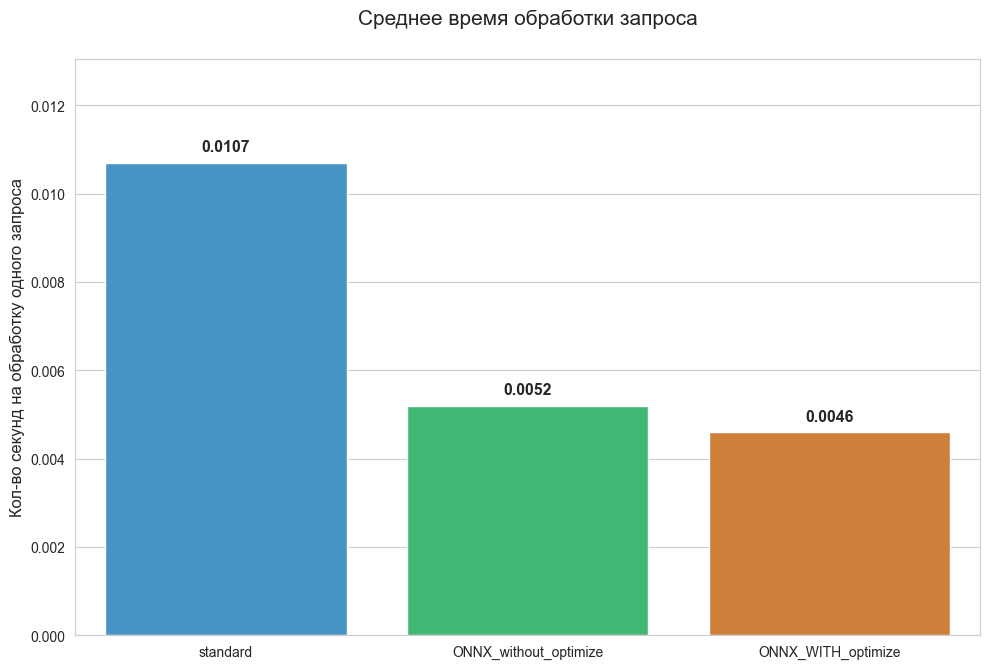

In [37]:
keys = list(mean_req_processing_time.keys())
values = list(mean_req_processing_time.values())

sns.set_style("whitegrid")
colors = ["#3498db", "#2ecc71", "#e67e22"]

plt.figure(figsize=(10, 6.8))
ax = sns.barplot(x=keys, y=values, palette=colors)

plt.title("Среднее время обработки запроса", fontsize=15, pad=25)
plt.ylabel("Кол-во секунд на обработку одного запроса", fontsize=12)

max_val = max(values)
plt.ylim(0, max_val * 1.22)  # костылем увеличим потолок, чтобы график был читабельным

for i, v in enumerate(values):
    ax.text(i, v + max_val * 0.018, f"{v:.4f}", 
            ha="center", va="bottom", 
            fontsize=11.5, fontweight="bold")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()